Week 18 · Day 1 — RL Intuition & Markov Decision Processes
Why this matters

Reinforcement Learning (RL) teaches agents to learn by doing — the foundation of modern game AIs, robotics, and autonomous systems. Today you’ll simulate how an agent interacts with its environment to maximize rewards.

Theory Essentials

Agent: the learner/decision-maker.

Environment: where it acts (the world).

State (s): the current situation.

Action (a): what the agent can do.

Reward (r): feedback signal (good/bad outcome).

Policy (π): rule mapping states to actions (π(a|s)).

Goal: maximize expected cumulative reward over time.

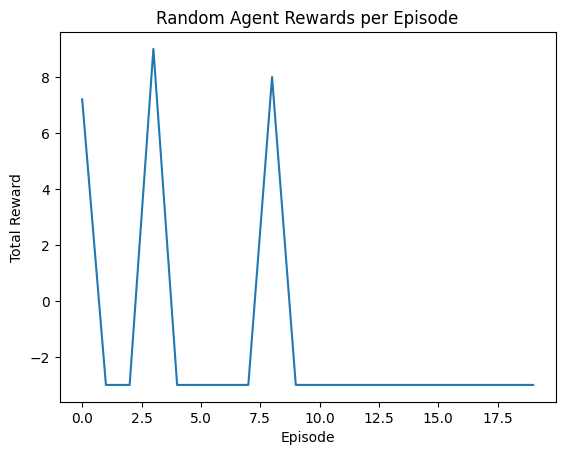

In [1]:
# Setup
import numpy as np, matplotlib.pyplot as plt
np.random.seed(42)

# Define a 5x5 grid world
grid_size = 5
goal = (4, 4)
actions = ['up', 'down', 'left', 'right']

# Reward map
rewards = np.zeros((grid_size, grid_size))
rewards[goal] = 10

def step(state, action):
    x, y = state
    if action == 'up': x = max(x-1, 0)
    elif action == 'down': x = min(x+1, grid_size-1)
    elif action == 'left': y = max(y-1, 0)
    elif action == 'right': y = min(y+1, grid_size-1)
    reward = rewards[x, y] - 0.1  # small step cost
    return (x, y), reward

# Simulate a random agent
n_episodes = 20
episode_rewards = []

for ep in range(n_episodes):
    state = (0, 0)
    total_reward = 0
    for t in range(30):
        action = np.random.choice(actions)
        state, r = step(state, action)
        total_reward += r
        if state == goal:
            break
    episode_rewards.append(total_reward)

plt.plot(episode_rewards)
plt.title("Random Agent Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()


Exactly ✅ — you’ve got it.

To restate clearly:

* **Each episode** = up to **30 steps** (moves).
* The agent starts at `(0,0)` with **total_reward = 0**.
* At each step:

  * It gets **−0.1** for moving.
  * If it lands on the goal `(4,4)`, it gets **+9.9** and the episode ends early.
* After those steps, you store the **final accumulated reward** (the total for that whole episode) in `episode_rewards`.

Then the plot:

```python
plt.plot(episode_rewards)
```

shows **one point per episode**, the **total reward collected during that episode** —
not a running total through time, and not step-by-step.

That’s why the x-axis is labeled *Episode*, not *Step*.
So: 20 points → 20 episodes, each summarizing up to 30 steps.


1) Core (10–15 min)

Task: Change the grid size and goal position; observe how often the random agent reaches it.

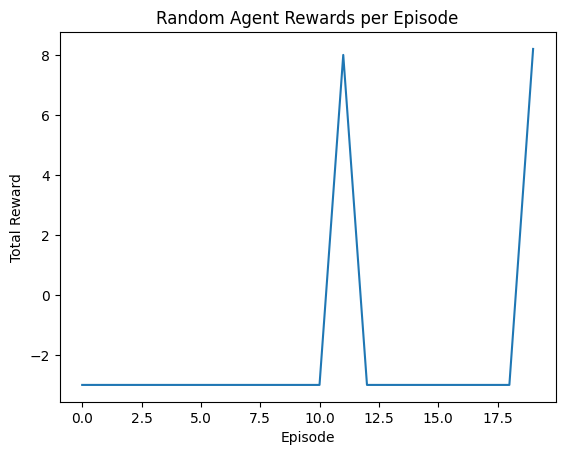

In [2]:
grid_size = 6
goal = (5, 2)

actions = ['up', 'down', 'left', 'right']

# Reward map
rewards = np.zeros((grid_size, grid_size))
rewards[goal] = 10

def step(state, action):
    x, y = state
    if action == 'up': x = max(x-1, 0)
    elif action == 'down': x = min(x+1, grid_size-1)
    elif action == 'left': y = max(y-1, 0)
    elif action == 'right': y = min(y+1, grid_size-1)
    reward = rewards[x, y] - 0.1  # small step cost
    return (x, y), reward

# Simulate a random agent
n_episodes = 20
episode_rewards = []

for ep in range(n_episodes):
    state = (0, 0)
    total_reward = 0
    for t in range(30):
        action = np.random.choice(actions)
        state, r = step(state, action)
        total_reward += r
        if state == goal:
            break
    episode_rewards.append(total_reward)

plt.plot(episode_rewards)
plt.title("Random Agent Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

2) Practice (10–15 min)

Task: Add an obstacle (negative reward zone) in the grid.

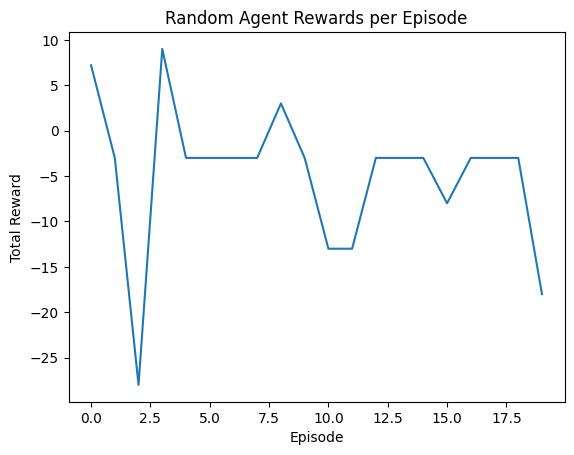

In [3]:
# Setup
import numpy as np, matplotlib.pyplot as plt
np.random.seed(42)

# Define a 5x5 grid world
grid_size = 5
goal = (4, 4)
actions = ['up', 'down', 'left', 'right']

# Reward map
rewards = np.zeros((grid_size, grid_size))
rewards[goal] = 10
rewards[2, 2] = -5


def step(state, action):
    x, y = state
    if action == 'up': x = max(x-1, 0)
    elif action == 'down': x = min(x+1, grid_size-1)
    elif action == 'left': y = max(y-1, 0)
    elif action == 'right': y = min(y+1, grid_size-1)
    reward = rewards[x, y] - 0.1  # small step cost
    return (x, y), reward

# Simulate a random agent
n_episodes = 20
episode_rewards = []

for ep in range(n_episodes):
    state = (0, 0)
    total_reward = 0
    for t in range(30):
        action = np.random.choice(actions)
        state, r = step(state, action)
        total_reward += r
        if state == goal:
            break
    episode_rewards.append(total_reward)

plt.plot(episode_rewards)
plt.title("Random Agent Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()


3) Stretch (optional, 10–15 min)

Task: Track and plot the trajectory (visited states) for one episode.

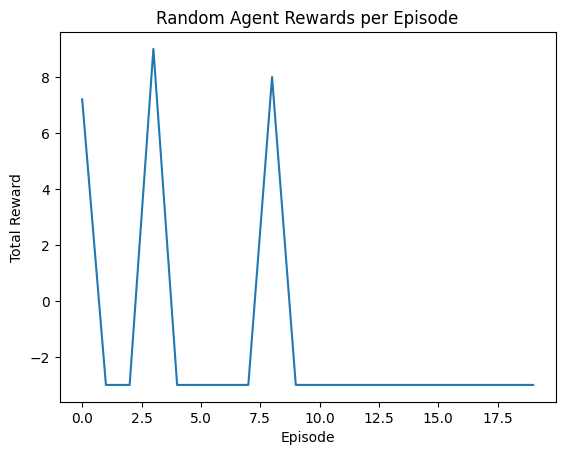

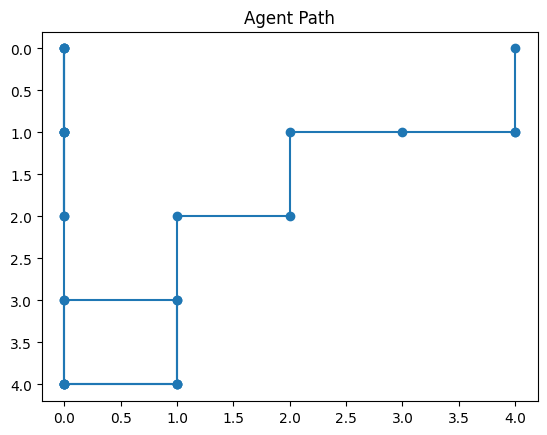

In [5]:
# Setup
import numpy as np, matplotlib.pyplot as plt
np.random.seed(42)

# Define a 5x5 grid world
grid_size = 5
goal = (4, 4)
actions = ['up', 'down', 'left', 'right']

# Reward map
rewards = np.zeros((grid_size, grid_size))
rewards[goal] = 10

def step(state, action):
    x, y = state
    if action == 'up': x = max(x-1, 0)
    elif action == 'down': x = min(x+1, grid_size-1)
    elif action == 'left': y = max(y-1, 0)
    elif action == 'right': y = min(y+1, grid_size-1)
    reward = rewards[x, y] - 0.1  # small step cost
    return (x, y), reward

# Simulate a random agent
n_episodes = 20
episode_rewards = []

for ep in range(n_episodes):
    state = (0, 0)
    total_reward = 0
    for t in range(30):
        action = np.random.choice(actions)
        state, r = step(state, action)
        total_reward += r
        if state == goal:
            break
    episode_rewards.append(total_reward)

plt.plot(episode_rewards)
plt.title("Random Agent Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

path = []
state = (0, 0)
for t in range(30):
    path.append(state)
    action = np.random.choice(actions)
    state, _ = step(state, action)
path = np.array(path)
plt.plot(path[:,1], path[:,0], 'o-')
plt.gca().invert_yaxis()
plt.title("Agent Path")
plt.show()


Mini-Challenge (≤40 min) — “Smarter Random Agent”

Goal: Build an agent that prefers moves toward the goal instead of pure randomness.

Acceptance Criteria:

Agent chooses actions with biased probability toward goal direction.

Achieves higher average rewards than the pure random agent.

Plot reward curves comparing both.

Pure Random:
  Avg reward: -1.626
  Success rate: 12.5% (25/200)
  Mean steps on successes: 20.0

Smarter Random:
  Avg reward: 7.982
  Success rate: 96.0% (192/200)
  Mean steps on successes: 15.6



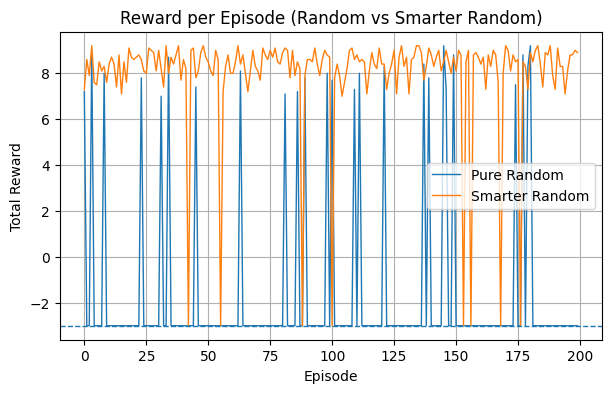

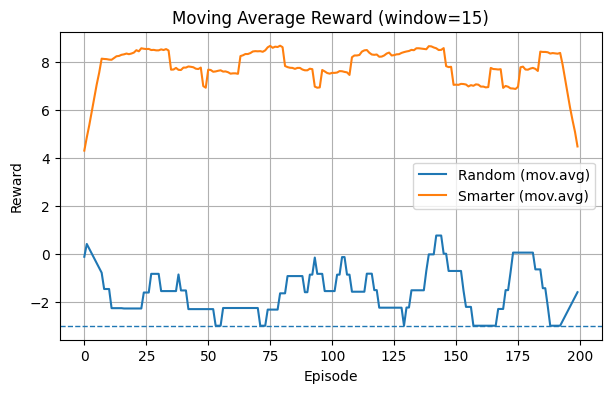

In [6]:
# Setup
import numpy as np, matplotlib.pyplot as plt
np.random.seed(42)
plt.rcParams["figure.figsize"] = (7,4)
plt.rcParams["axes.grid"] = True

# ----- Environment (same rules as your code) -----
grid_size = 5
goal = (4, 4)
actions = ['up', 'down', 'left', 'right']

rewards_map = np.zeros((grid_size, grid_size))
rewards_map[goal] = 10

def step(state, action):
    x, y = state
    if action == 'up':    x = max(x-1, 0)
    elif action == 'down': x = min(x+1, grid_size-1)
    elif action == 'left': y = max(y-1, 0)
    elif action == 'right': y = min(y+1, grid_size-1)
    reward = rewards_map[x, y] - 0.1  # step cost
    return (x, y), reward

# ----- Policies -----
def random_policy(state):
    return np.random.choice(actions)

def smart_policy(state):
    """
    Bias toward actions that REDUCE Manhattan distance to the goal.
    Uses a simple linear scoring -> normalized to probabilities.
    """
    x, y = state
    gx, gy = goal
    def next_state(s, a):
        x, y = s
        if a == 'up':    x = max(x-1, 0)
        if a == 'down':  x = min(x+1, grid_size-1)
        if a == 'left':  y = max(y-1, 0)
        if a == 'right': y = min(y+1, grid_size-1)
        return (x, y)

    cur_dist = abs(gx - x) + abs(gy - y)
    scores = []
    for a in actions:
        nx, ny = next_state(state, a)
        new_dist = abs(gx - nx) + abs(gy - ny)
        improvement = cur_dist - new_dist      # >0 if closer, 0 if same, <0 if farther
        score = 0.1 + 0.25 * max(improvement, 0.0)  # bonus only if closer
        # tiny epsilon so non-preferred actions still possible (exploration)
        scores.append(score + 1e-6)

    probs = np.array(scores) / np.sum(scores)
    return np.random.choice(actions, p=probs)

# ----- Simulator -----
def simulate(policy_fn, n_episodes=200, max_steps=30):
    ep_rewards, success_flags, success_steps = [], [], []
    for _ in range(n_episodes):
        state = (0, 0)
        total = 0.0
        for t in range(1, max_steps+1):
            a = policy_fn(state)
            state, r = step(state, a)
            total += r
            if state == goal:
                success_flags.append(1)
                success_steps.append(t)
                break
        else:
            success_flags.append(0)
        ep_rewards.append(total)
    return np.array(ep_rewards), np.array(success_flags), np.array(success_steps)

# ----- Run both agents -----
n_episodes = 200
rand_rewards, rand_succ, rand_steps = simulate(random_policy, n_episodes)
smart_rewards, smart_succ, smart_steps = simulate(smart_policy, n_episodes)

# ----- Stats -----
def summarize(name, rewards, succ, steps):
    solved = rewards > -3.0  # reached goal => not stuck at -3
    print(f"{name}:")
    print(f"  Avg reward: {rewards.mean():.3f}")
    print(f"  Success rate: {solved.mean()*100:.1f}% ({solved.sum()}/{len(rewards)})")
    if len(steps) > 0:
        print(f"  Mean steps on successes: {steps.mean():.1f}")
    print()

summarize("Pure Random", rand_rewards, rand_succ, rand_steps)
summarize("Smarter Random", smart_rewards, smart_succ, smart_steps)

# ----- Plot -----
plt.figure()
plt.plot(rand_rewards, linewidth=1, label="Pure Random")
plt.plot(smart_rewards, linewidth=1, label="Smarter Random")
plt.axhline(-3, linestyle="--", linewidth=1)  # fail line (no goal reached)
plt.title("Reward per Episode (Random vs Smarter Random)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.show()

# Optional: moving average for clarity
def moving_avg(x, k=10):
    k = max(1, k)
    return np.convolve(x, np.ones(k)/k, mode='same')

plt.figure()
plt.plot(moving_avg(rand_rewards, 15), label="Random (mov.avg)")
plt.plot(moving_avg(smart_rewards, 15), label="Smarter (mov.avg)")
plt.axhline(-3, linestyle="--", linewidth=1)
plt.title("Moving Average Reward (window=15)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.show()


Notes / Key Takeaways

RL ≠ supervised learning — it learns from consequences, not labels.

The Markov property: next state depends only on current state + action.

Rewards shape behavior; poor design → unintended strategies.

Even random agents can learn over time when combined with value estimation.

Visualization helps intuit agent–environment dynamics.

Reflection

What does “maximizing cumulative reward” mean in real-world terms?

How is this setup different from supervised learning you’ve done before?

1. What does “maximizing cumulative reward” mean in real-world terms?
It means learning to make a series of decisions that lead to the best overall outcome over time — not just the best immediate one.
For example, a robot vacuum might skip cleaning a small nearby spot now if that helps it save battery and reach the charging station later. It’s optimizing for total efficiency (long-term reward), not just short-term gain.

2. How is this setup different from supervised learning you’ve done before?
In supervised learning, the model is trained on labeled data — it’s told the correct answer for each input.
In reinforcement learning, the agent learns by trial and error: it doesn’t get explicit answers, only feedback in the form of rewards or penalties based on its actions. It has to discover which actions lead to higher cumulative rewards through experience.